In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

In [2]:
# Load dataset
df = pd.read_csv('data.csv')
df

,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,...,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
0,5000,3,1,1,Salried,2,125 to 150,4866,28,1,...,Unknown,NaN,Chennai,67,N,Rare,Moderate,1,25,20978
1,5001,0,0,0,Student,4,150 to 175,6411,50,0,...,formerly smoked,NaN,Jaipur,58,N,Rare,Moderate,3,27,6170
2,5002,1,0,0,Business,4,200 to 225,4509,68,0,...,formerly smoked,NaN,Jaipur,73,N,Daily,Extreme,0,32,28382
3,5003,7,4,0,Business,2,175 to 200,6214,51,0,...,Unknown,NaN,Chennai,71,Y,Rare,No,3,37,27148
4,5004,3,1,0,Student,2,150 to 175,4938,44,0,...,never smoked,2004.0,Bangalore,74,N,No,Extreme,0,34,29616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,29995,3,0,0,Salried,4,225 to 250,5614,22,0,...,smokes,2000.0,Kanpur,79,Y,Rare,Moderate,4,40,39488
24996,29996,6,0,0,Business,4,200 to 225,4719,58,0,...,never smoked,2009.0,Kanpur,66,N,Rare,Moderate,2,28,14808
24997,29997,7,0,1,Student,2,150 to 175,5624,34,0,...,Unknown,NaN,Bhubaneswar,76,N,Rare,Moderate,1,35,33318
24998,29998,1,0,0,Salried,2,225 to 250,10777,27,0,...,Unknown,NaN,Surat,74,N,Rare,Moderate,0,40,30850


In [3]:
pd.options.display.max_columns = None

In [4]:
df.head()

,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,other_major_decs_history,Gender,avg_glucose_level,bmi,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
0,5000,3,1,1,Salried,2,125 to 150,4866,28,1,0,Male,97,31.2,Unknown,NaN,Chennai,67,N,Rare,Moderate,1,25,20978
1,5001,0,0,0,Student,4,150 to 175,6411,50,0,0,Male,212,34.2,formerly smoked,NaN,Jaipur,58,N,Rare,Moderate,3,27,6170
2,5002,1,0,0,Business,4,200 to 225,4509,68,0,0,Female,166,40.4,formerly smoked,NaN,Jaipur,73,N,Daily,Extreme,0,32,28382
3,5003,7,4,0,Business,2,175 to 200,6214,51,0,0,Female,109,22.9,Unknown,NaN,Chennai,71,Y,Rare,No,3,37,27148
4,5004,3,1,0,Student,2,150 to 175,4938,44,0,1,Male,118,26.5,never smoked,2004.0,Bangalore,74,N,No,Extreme,0,34,29616


In [5]:
df.tail()

,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,other_major_decs_history,Gender,avg_glucose_level,bmi,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
24995,29995,3,0,0,Salried,4,225 to 250,5614,22,0,0,Male,145,36.1,smokes,2000.0,Kanpur,79,Y,Rare,Moderate,4,40,39488
24996,29996,6,0,0,Business,4,200 to 225,4719,58,0,0,Male,134,31.3,never smoked,2009.0,Kanpur,66,N,Rare,Moderate,2,28,14808
24997,29997,7,0,1,Student,2,150 to 175,5624,34,0,1,Male,151,NaN,Unknown,NaN,Bhubaneswar,76,N,Rare,Moderate,1,35,33318
24998,29998,1,0,0,Salried,2,225 to 250,10777,27,0,0,Male,66,26.6,Unknown,NaN,Surat,74,N,Rare,Moderate,0,40,30850
24999,29999,8,2,0,Business,4,150 to 175,5882,22,1,0,Male,245,41.6,formerly smoked,2014.0,Chennai,57,N,No,No,4,21,6170


In [6]:
# Dimensions of the dataset
df.shape

(25000, 24)

In [7]:
# Information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   applicant_id                    25000 non-null  int64  
 1   years_of_insurance_with_us      25000 non-null  int64  
 2   regular_checkup_lasy_year       25000 non-null  int64  
 3   adventure_sports                25000 non-null  int64  
 4   Occupation                      25000 non-null  object 
 5   visited_doctor_last_1_year      25000 non-null  int64  
 6   cholesterol_level               25000 non-null  object 
 7   daily_avg_steps                 25000 non-null  int64  
 8   age                             25000 non-null  int64  
 9   heart_decs_history              25000 non-null  int64  
 10  other_major_decs_history        25000 non-null  int64  
 11  Gender                          25000 non-null  object 
 12  avg_glucose_level               

In [8]:
# Cheking missing value
df.isnull().sum()

applicant_id                          0
years_of_insurance_with_us            0
regular_checkup_lasy_year             0
adventure_sports                      0
Occupation                            0
visited_doctor_last_1_year            0
cholesterol_level                     0
daily_avg_steps                       0
age                                   0
heart_decs_history                    0
other_major_decs_history              0
Gender                                0
avg_glucose_level                     0
bmi                                 990
smoking_status                        0
Year_last_admitted                11881
Location                              0
weight                                0
covered_by_any_other_company          0
Alcohol                               0
exercise                              0
weight_change_in_last_one_year        0
fat_percentage                        0
insurance_cost                        0
dtype: int64

In [9]:
# checking for duplicate values
df.duplicated().sum() 

0

In [10]:
# Descriptive summary of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
applicant_id,25000.0,17499.500000,7217.022701,5000.0,11249.75,17499.5,23749.25,29999.0
years_of_insurance_with_us,25000.0,4.089040,2.606612,0.0,2.00,4.0,6.00,8.0
regular_checkup_lasy_year,25000.0,0.773680,1.199449,0.0,0.00,0.0,1.00,5.0
adventure_sports,25000.0,0.081720,0.273943,0.0,0.00,0.0,0.00,1.0
visited_doctor_last_1_year,25000.0,3.104200,1.141663,0.0,2.00,3.0,4.00,12.0
daily_avg_steps,25000.0,5215.889320,1053.179748,2034.0,4543.00,5089.0,5730.00,11255.0
age,25000.0,44.918320,16.107492,16.0,31.00,45.0,59.00,74.0
heart_decs_history,25000.0,0.054640,0.227281,0.0,0.00,0.0,0.00,1.0
other_major_decs_history,25000.0,0.098160,0.297537,0.0,0.00,0.0,0.00,1.0
avg_glucose_level,25000.0,167.530000,62.729712,57.0,113.00,168.0,222.00,277.0


- We see that the applicant_id and Year_last_admitted columns are not going to relevant for the analysis- 
So we will drop these variables

In [11]:
df.drop(['applicant_id', 'Year_last_admitted'], axis = 1, inplace = True)

In [12]:
# in the 'bmi' columns there are some missing values are present we impute that with mean
df['bmi'].fillna(df['bmi'].mean(), inplace = True)

C:\Users\nilan\AppData\Local\Temp\ipykernel_45964\3927449067.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(), inplace = True)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   years_of_insurance_with_us      25000 non-null  int64  
 1   regular_checkup_lasy_year       25000 non-null  int64  
 2   adventure_sports                25000 non-null  int64  
 3   Occupation                      25000 non-null  object 
 4   visited_doctor_last_1_year      25000 non-null  int64  
 5   cholesterol_level               25000 non-null  object 
 6   daily_avg_steps                 25000 non-null  int64  
 7   age                             25000 non-null  int64  
 8   heart_decs_history              25000 non-null  int64  
 9   other_major_decs_history        25000 non-null  int64  
 10  Gender                          25000 non-null  object 
 11  avg_glucose_level               25000 non-null  int64  
 12  bmi                             

# Univariate Analysis

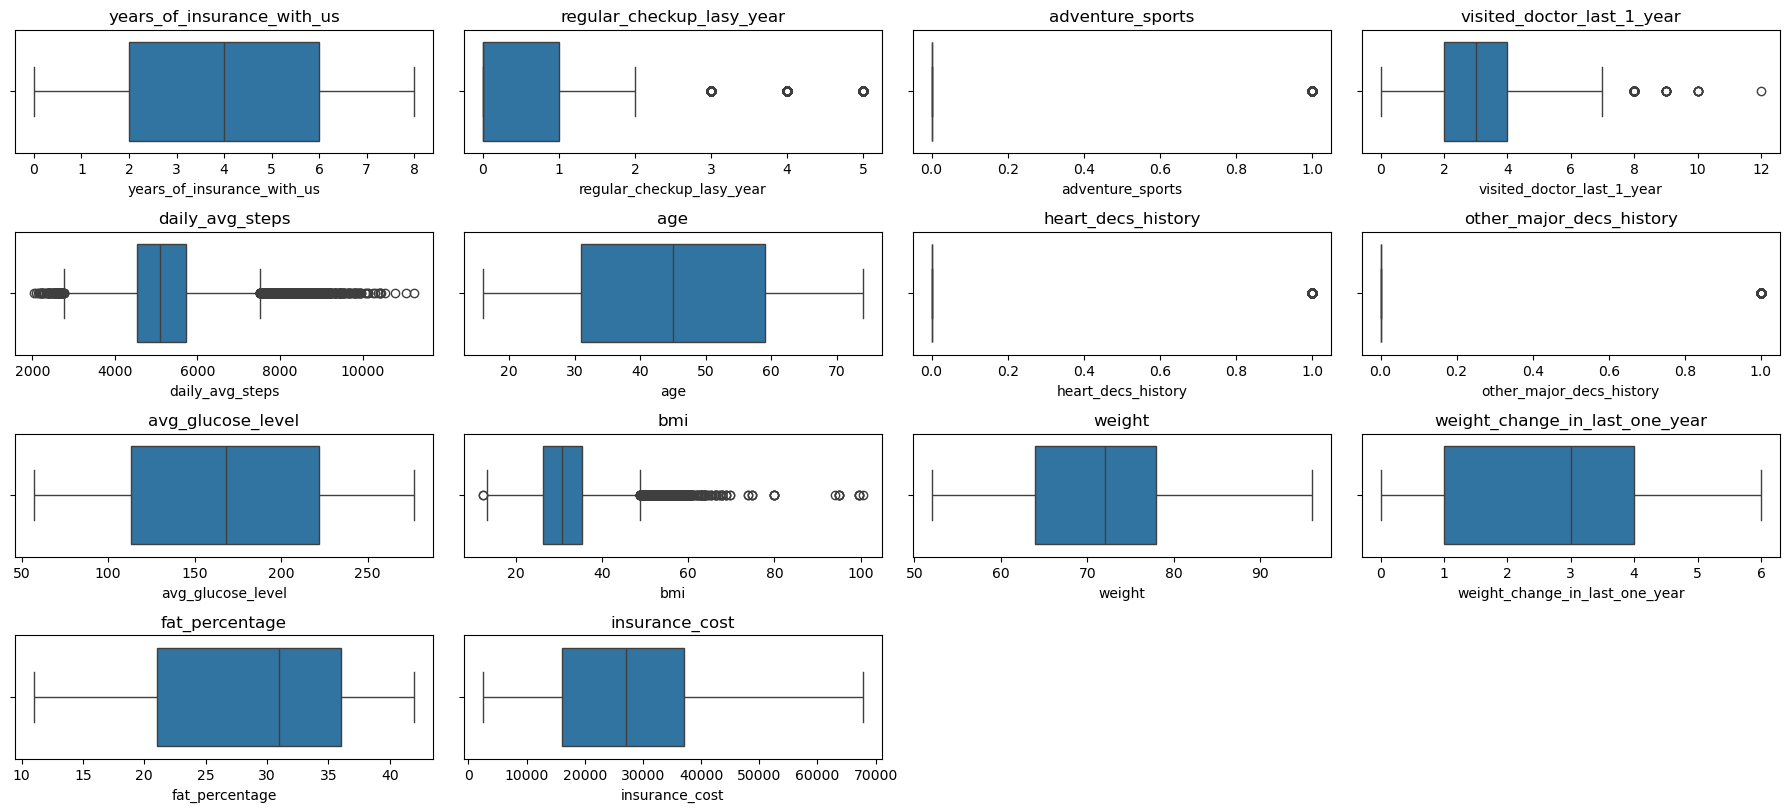

In [14]:
#Get boxplots for all the numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(18, 30))

for i, variable in enumerate(numeric_columns):
    plt.subplot(15, 4, i + 1)
    sns.boxplot(data=df, x=variable)
    plt.tight_layout()
    plt.title(variable)
plt.show()

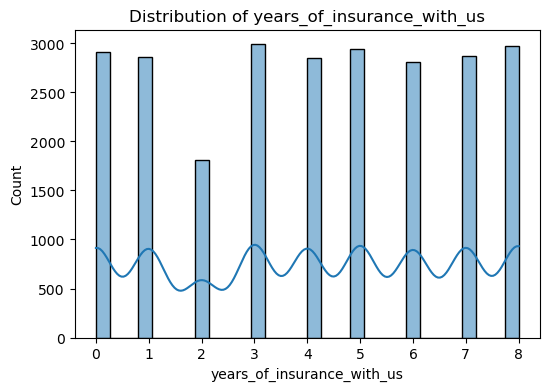

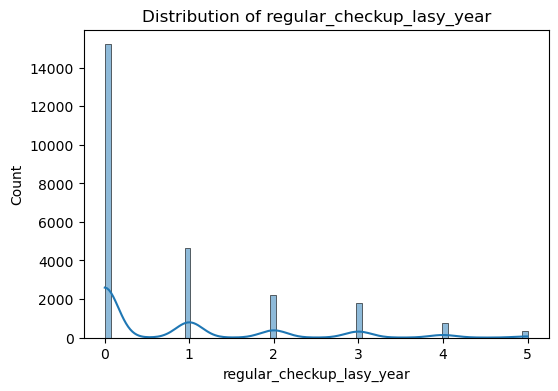

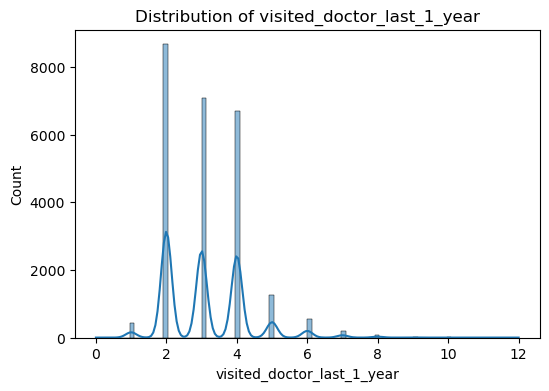

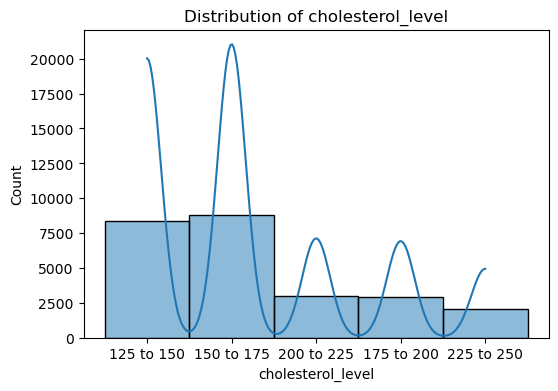

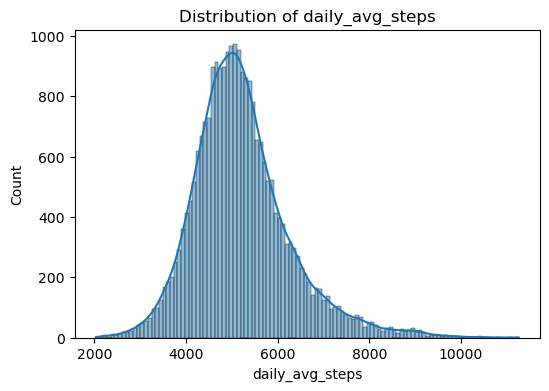

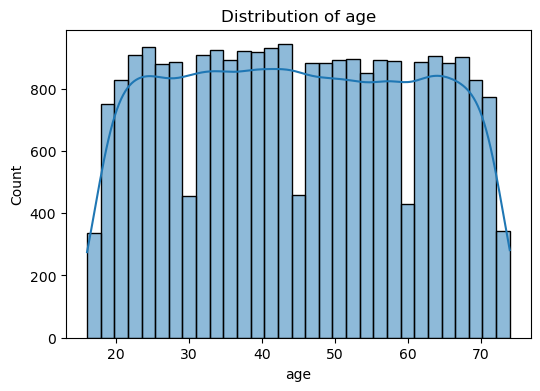

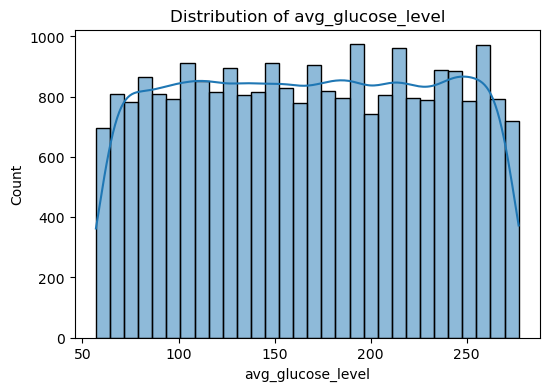

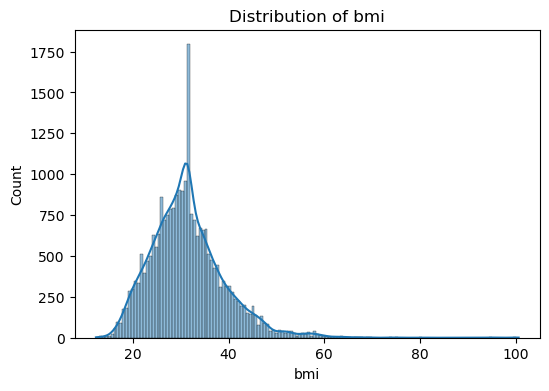

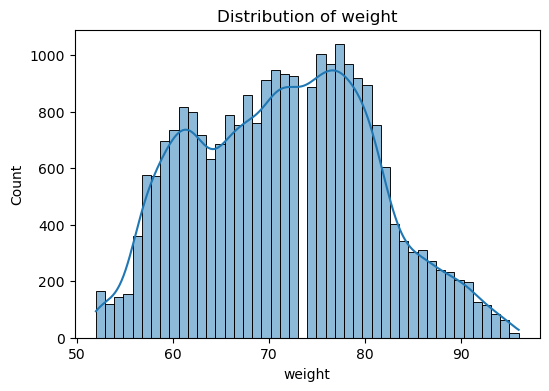

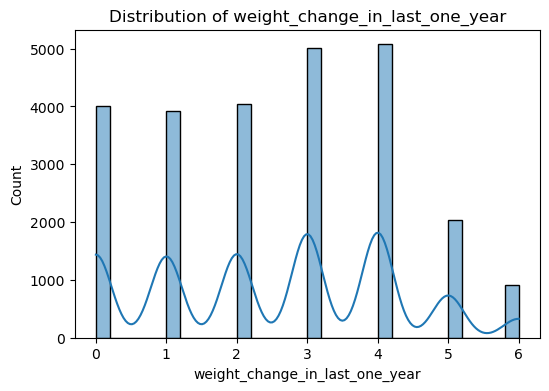

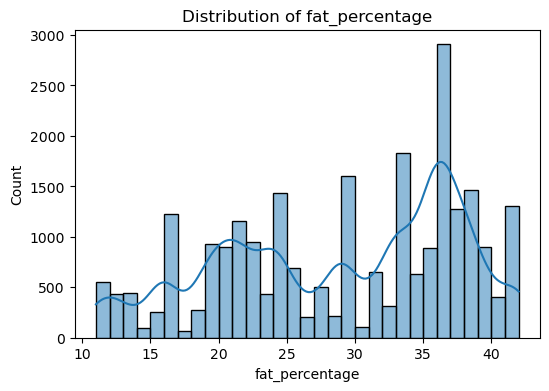

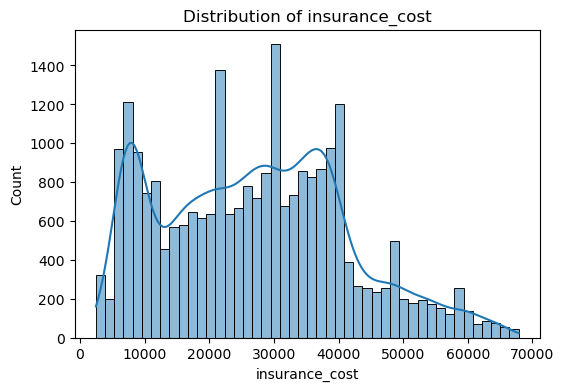

In [15]:
continuous_columns = ['years_of_insurance_with_us', 'regular_checkup_lasy_year', 
                      'visited_doctor_last_1_year', 'cholesterol_level', 
                      'daily_avg_steps', 'age', 'avg_glucose_level', 
                      'bmi', 'weight', 'weight_change_in_last_one_year', 
                      'fat_percentage', 'insurance_cost']

for col in continuous_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

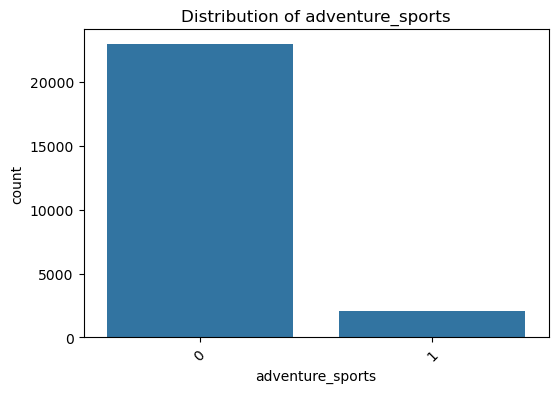

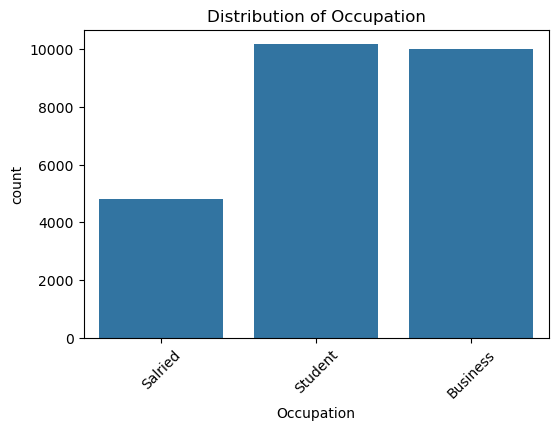

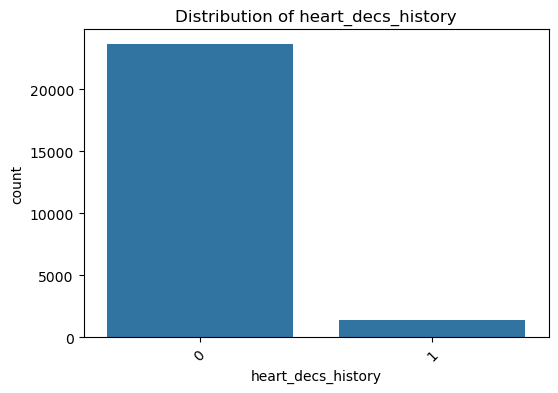

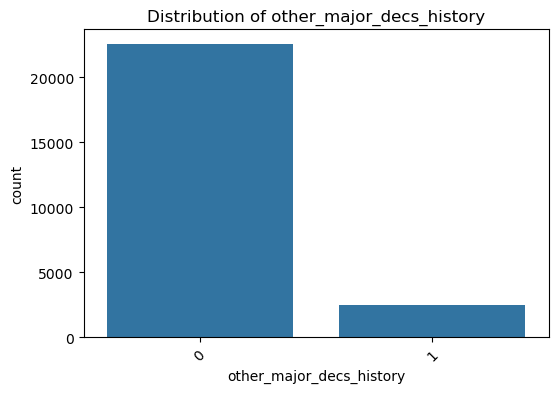

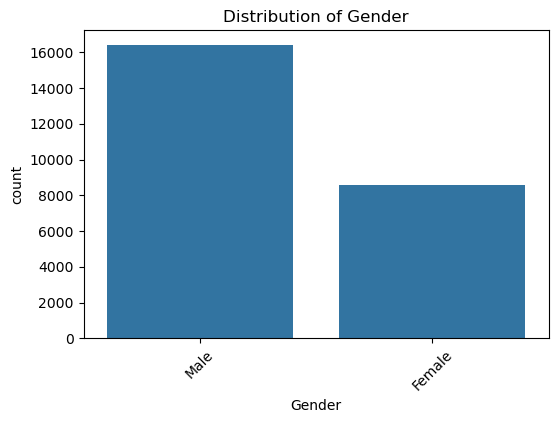

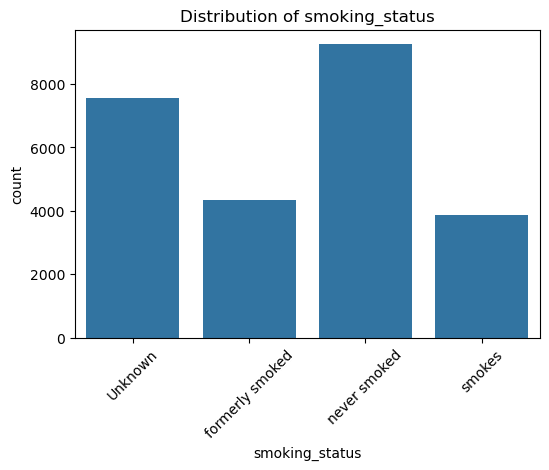

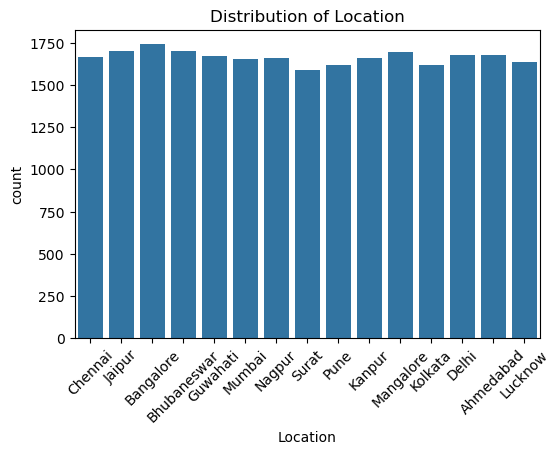

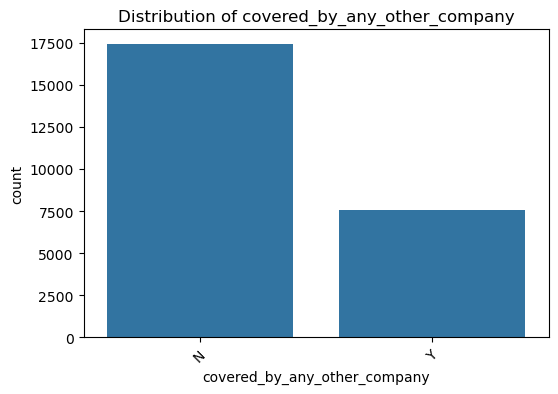

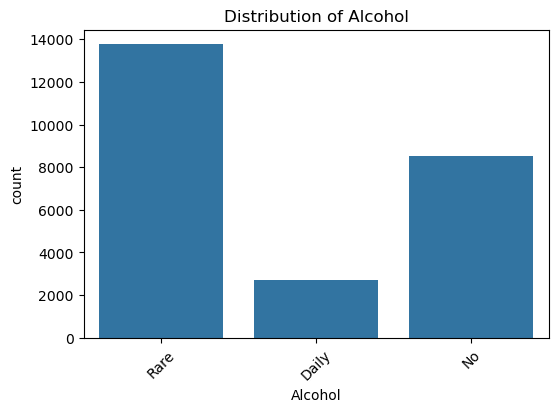

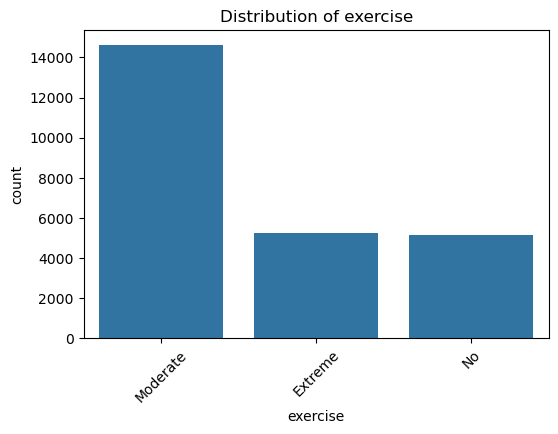

In [16]:
categorical_columns = ['adventure_sports', 'Occupation', 'heart_decs_history', 
                       'other_major_decs_history', 'Gender', 'smoking_status', 
                       'Location', 'covered_by_any_other_company', 'Alcohol', 
                       'exercise']
for col in categorical_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

# Bivariate Analysis

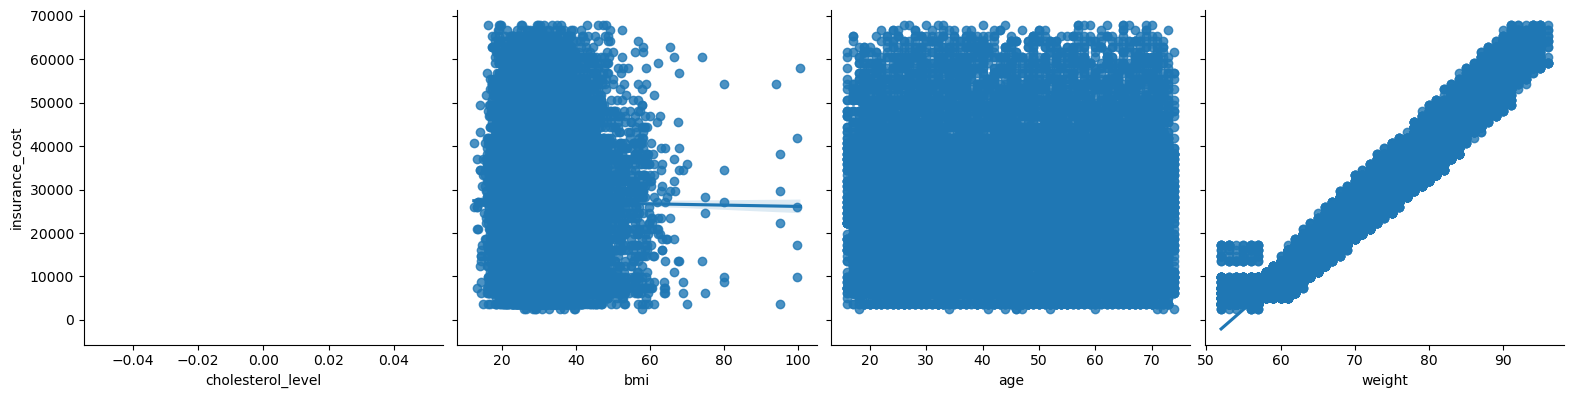

In [17]:
numeric_columns = ['cholesterol_level', 'bmi', 'age', 'weight', 'insurance_cost']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
sns.pairplot(df, x_vars=['cholesterol_level', 'bmi', 'age', 'weight'], 
             y_vars='insurance_cost', kind='reg', height=4)
plt.show()

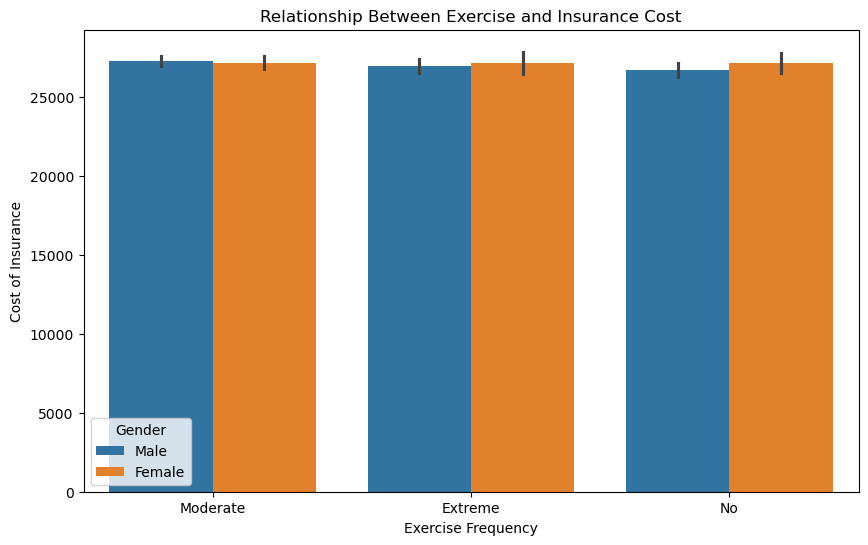

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x='exercise', y='insurance_cost', hue='Gender', data=df)
plt.title('Relationship Between Exercise and Insurance Cost')
plt.xlabel('Exercise Frequency')
plt.ylabel('Cost of Insurance')
plt.show()


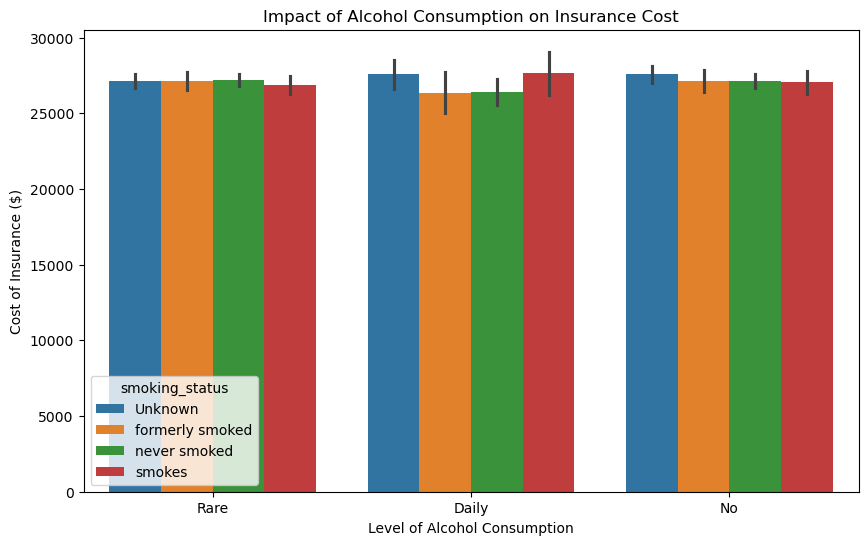

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Alcohol', y='insurance_cost', hue='smoking_status', data=df)
plt.title('Impact of Alcohol Consumption on Insurance Cost')
plt.xlabel('Level of Alcohol Consumption')
plt.ylabel('Cost of Insurance ($)')
plt.show()

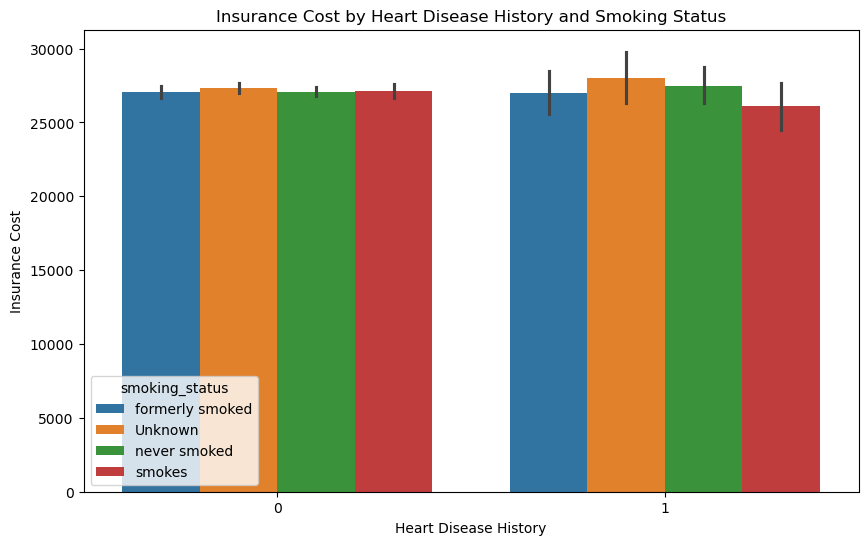

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x='heart_decs_history', y='insurance_cost', hue='smoking_status', data=df)
plt.title('Insurance Cost by Heart Disease History and Smoking Status')
plt.xlabel('Heart Disease History')
plt.ylabel('Insurance Cost')
plt.show()

In [21]:
# Outlier treatment
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

columns_with_outliers = ['regular_checkup_lasy_year', 'adventure_sports', 'visited_doctor_last_1_year', 'daily_avg_steps', 'heart_decs_history', 'other_major_decs_history', 'bmi']
for column in columns_with_outliers:
    cap_outliers_iqr(df, column)

In [22]:
# Check for data imbalance
print("Value Counts for Categorical Variables:")
for col in ['Gender', 'smoking_status', 'Location']:
    print(df[col].value_counts())

Value Counts for Categorical Variables:
Gender
Male      16422
Female     8578
Name: count, dtype: int64
smoking_status
never smoked       9249
Unknown            7555
formerly smoked    4329
smokes             3867
Name: count, dtype: int64
Location
Bangalore      1742
Jaipur         1706
Bhubaneswar    1704
Mangalore      1697
Delhi          1680
Ahmedabad      1677
Guwahati       1672
Chennai        1669
Kanpur         1664
Nagpur         1663
Mumbai         1658
Lucknow        1637
Pune           1622
Kolkata        1620
Surat          1589
Name: count, dtype: int64


In [23]:
# Clustering on numerical variables only
numerical_features = df[['age', 'bmi', 'insurance_cost']]
scaler = StandardScaler()
numerical_features_scaled = scaler.fit_transform(numerical_features)


In [24]:
# Applying KMeans for 3 clusters
kmeans = KMeans(n_clusters=3, random_state=0)
df['Cluster'] = kmeans.fit_predict(numerical_features_scaled)

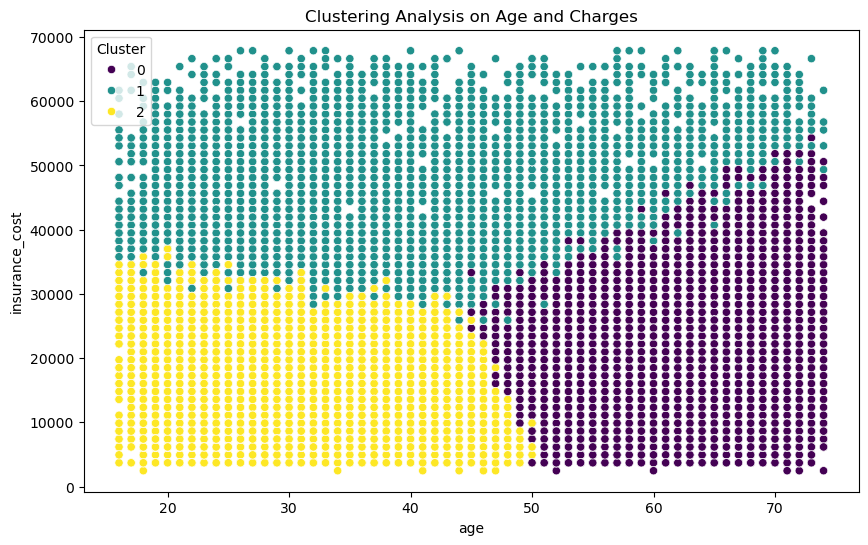

In [25]:
# Visualizing clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='insurance_cost', hue='Cluster', palette='viridis')
plt.title('Clustering Analysis on Age and Charges')
plt.show()

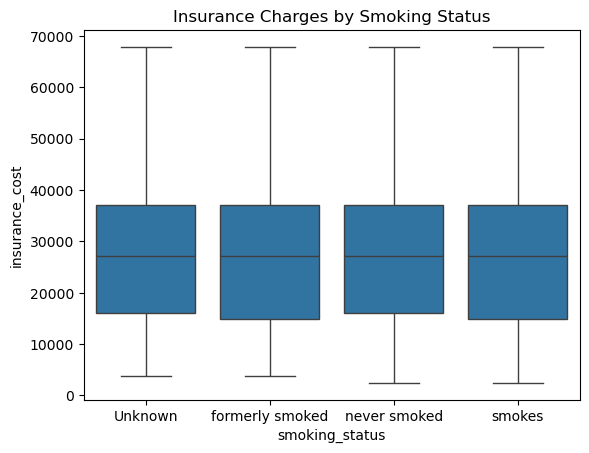

In [26]:
# Further insights may involve analyzing the differences in charges between smokers and non-smokers, as well as identifying regions associated with higher charges.
sns.boxplot(data=df, x='smoking_status', y='insurance_cost')
plt.title('Insurance Charges by Smoking Status')
plt.show()

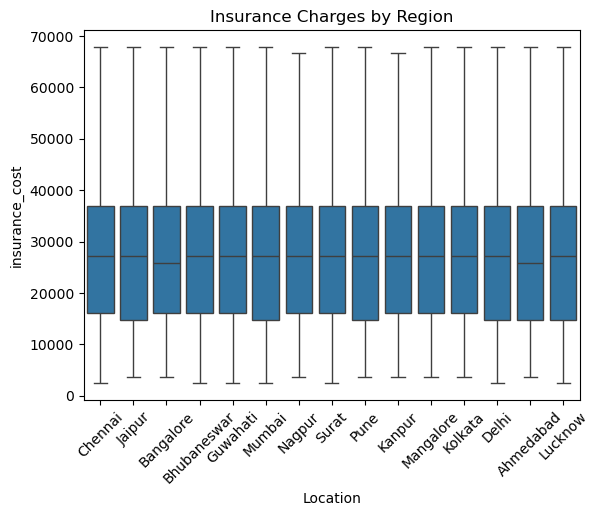

In [27]:
sns.boxplot(data=df, x='Location', y='insurance_cost')
plt.title('Insurance Charges by Region')
plt.xticks(rotation=45)
plt.show()